# **Superpixel Segmentation: SLIC, SEEDS & LSC**

## **Objectives:**
1. Oversegment an image into perceptually-meaningful atomic regions with `cv2.ximgproc`'s three superpixel algorithms — no external model, no new dependency
2. Compare superpixel count, boundary quality, and runtime across SLIC, SEEDS, and LSC
3. Test superpixels' core property — never straddling a real local edge — directly against notebook 22's marker-based Watershed on the same `coins.jpg`, and find a real case where Watershed's exact tuned pipeline actually fails

> **Assets.** No new files — this reuses notebook 22's exact `assets/images/coins.jpg`. `cv2.ximgproc` (SLIC, SEEDS, and LSC are all built in) ships in the `opencv-contrib` wheel this repo already pins, confirmed working with zero setup changes on both `opencv-contrib-python-headless==4.10.0.84` (this notebook's environment) and `==5.0.0.93` (notebook 34's `.venv5x`).

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **A completely different philosophy from Watershed**

Notebook 22's Watershed tries to solve the whole problem in one shot: find markers, flood-fill from them, and hope every marker lands on exactly one real object. When that global seeding step misjudges an image — as we'll see below — the whole segmentation is wrong for that region, with no local recovery.

Superpixel algorithms don't even try for "one region per object." They deliberately **oversegment**: hundreds of small, roughly-uniform patches instead of one blob per coin, each formed by a purely *local* decision (nearby pixels with similar color, in a size-bounded neighborhood, cluster together; a real color/intensity edge stops the cluster from growing across it). The trade is explicit — you don't get "here are the 24 coins" for free, you get "here are ~285 small, safe regions that respect real edges," and grouping those into actual objects is left as a separate step you'd build on top. What you get in return is a much stronger guarantee: a decision that's purely local can't fail the way a single global threshold can.

## **Three algorithms, one image**

- **SLIC** (Simple Linear Iterative Clustering) — k-means clustering in a 5D (L, a, b, x, y) space, restricted to a local search window per cluster. The `SLICO` variant used here adapts each superpixel's compactness automatically instead of needing a hand-tuned weight.
- **SEEDS** — starts from a coarse grid and evolves boundaries pixel-by-pixel to minimize a color-histogram energy; typically the fastest of the three.
- **LSC** (Linear Spectral Clustering) — reformulates the clustering as a weighted k-means in a feature space chosen so results approximate normalized cuts, without needing an eigendecomposition.

SLIC  :  285 superpixels,  29.8 ms
SEEDS :  192 superpixels,   5.8 ms
LSC   :  285 superpixels,  33.9 ms


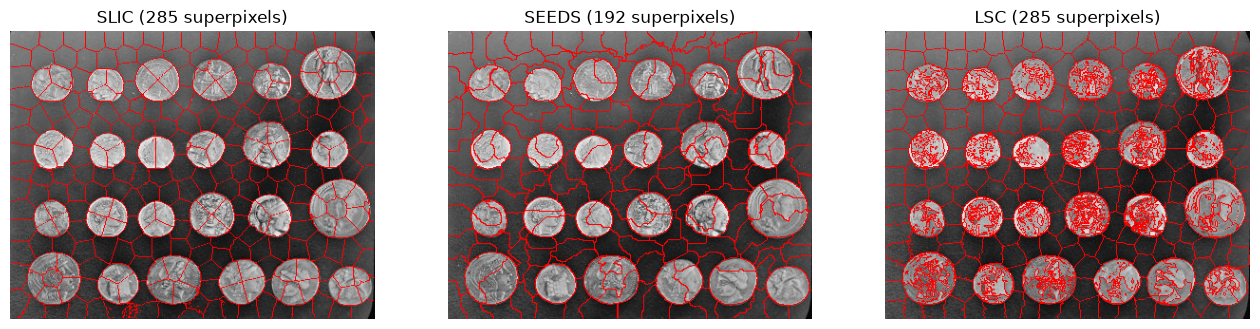

In [2]:
import time

img = cv2.imread('assets/images/coins.jpg')

def run_slic(img, region_size=20):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    algo = cv2.ximgproc.createSuperpixelSLIC(lab, algorithm=cv2.ximgproc.SLICO, region_size=region_size)
    t0 = time.perf_counter(); algo.iterate(10); t = time.perf_counter() - t0
    return algo.getNumberOfSuperpixels(), t, algo.getLabelContourMask(), algo.getLabels()

def run_seeds(img, num_superpixels=250):
    h, w = img.shape[:2]
    algo = cv2.ximgproc.createSuperpixelSEEDS(w, h, img.shape[2], num_superpixels, num_levels=4)
    t0 = time.perf_counter(); algo.iterate(img, 10); t = time.perf_counter() - t0
    return algo.getNumberOfSuperpixels(), t, algo.getLabelContourMask(), algo.getLabels()

def run_lsc(img, region_size=20):
    algo = cv2.ximgproc.createSuperpixelLSC(img, region_size=region_size)
    t0 = time.perf_counter(); algo.iterate(10); t = time.perf_counter() - t0
    return algo.getNumberOfSuperpixels(), t, algo.getLabelContourMask(), algo.getLabels()

results = {}
for name, fn in [('SLIC', run_slic), ('SEEDS', run_seeds), ('LSC', run_lsc)]:
    n, t, mask, labels = fn(img)
    results[name] = (n, t, mask, labels)
    print(f'{name:6s}: {n:4d} superpixels, {t*1000:5.1f} ms')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, results):
    n, t, mask, labels = results[name]
    vis = img.copy()
    vis[mask == 255] = (0, 0, 255)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{name} ({n} superpixels)')
    ax.axis('off')
plt.show()

Notice LSC's boundaries above are visibly noisier *inside* each coin than SLIC's — it's picking up the coins' own engraved detail as internal edges, not just the coin-to-background and coin-to-coin boundaries. All three still agree on the boundaries that matter most for the test below: none of them ever merge two neighboring coins into one region.

## **The real test: does Watershed actually separate these coins?**

Rerunning notebook 22's exact pipeline — same thresholds, same kernel, same `0.7 * dist_transform.max()` cutoff — and, instead of just eyeballing the result, actually **counting** what it produced.

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
ws_markers = cv2.watershed(img.copy(), markers)

n_regions = len(set(ws_markers.flatten())) - 2  # exclude background(1) and boundary(-1)
print(f'Watershed produced {n_regions} regions for a scene with 24 real coins.')
print('(notebook 22 never counts this — see for yourself what the blue boundary lines above it actually enclose)')

Watershed produced 6 regions for a scene with 24 real coins.
(notebook 22 never counts this — see for yourself what the blue boundary lines above it actually enclose)


Not 24 — a handful. The `0.7` sure-foreground threshold, tuned by eye against this image, is too aggressive for coins this size: much of each coin's interior never clears it, so those pixels get flooded from the *background* seed instead of a foreground one, and touching coins in the same row merge into a single region.

Concretely: pick a few coin-center points that are visibly touching their neighbor, and check what marker each one actually ended up with.

In [4]:
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
slic = cv2.ximgproc.createSuperpixelSLIC(lab, algorithm=cv2.ximgproc.SLICO, region_size=20)
slic.iterate(10)
sp_labels = slic.getLabels()

# Visually-verified touching-coin-pair centers (image coordinates)
pairs = [
    ((307, 38), (334, 43), 'top-right pair, row 1'),
    ((51, 258), (33, 271), 'bottom-left pair, row 4'),
    ((112, 210), (82, 195), 'row 2/3 boundary pair'),
]
print(f'{"pair":28s}  {"SLIC":22s}  {"Watershed"}')
for (x1, y1), (x2, y2), label in pairs:
    sp1, sp2 = sp_labels[y1, x1], sp_labels[y2, x2]
    ws1, ws2 = ws_markers[y1, x1], ws_markers[y2, x2]
    sp_verdict = 'different superpixels (correct)' if sp1 != sp2 else 'SAME superpixel (wrong)'
    ws_verdict = 'different markers (correct)' if ws1 != ws2 else f'SAME marker={ws1} (wrong)'
    print(f'{label:28s}  {sp_verdict:30s}  {ws_verdict}')

pair                          SLIC                    Watershed
top-right pair, row 1         different superpixels (correct)  SAME marker=1 (wrong)
bottom-left pair, row 4       different superpixels (correct)  SAME marker=1 (wrong)
row 2/3 boundary pair         different superpixels (correct)  SAME marker=1 (wrong)


## **Why this happens, and what it does/doesn't prove**

Every one of those pairs gets the *same* Watershed marker — and it's marker `1`, the sure-*background* id, meaning those coin-center pixels weren't even claimed as foreground at all. SLIC gets every pair right, because its clustering decision at each point only ever looks at nearby pixels — it has no single global threshold that can be wrong for the whole image at once.

This isn't "superpixels are better than Watershed" as a general claim — it's a specific, real failure of *this threshold* (`0.7`) on *this image*'s coin sizes, and notebook 22's further-reading section already suggests checking the pre-watershed marker count for exactly this reason. Retune that `0.7` down and Watershed likely catches up on this particular scene. The deeper, general point is architectural: Watershed's correctness rests on one global choice being right everywhere in the image; a superpixel's correctness rests on a local decision that only has to be right in its own small neighborhood — which is why superpixels are commonly used as the *safe first stage* feeding into something else (a region-merging step, a CRF, a learned classifier per superpixel), rather than as a complete segmentation on their own.

### A couple of things worth poking at

- Lower notebook 22's `0.7` sure-foreground threshold (try `0.4-0.5`) and rerun the marker count above — see how much of Watershed's failure here was really just that one number, not the algorithm itself.
- Build the "later step" superpixels are meant to feed: merge adjacent SLIC superpixels whose mean colors are close (a simple region-adjacency-graph merge) and see how close the result gets to 24 separate coins without ever using a global threshold.
- Run SLIC on `assets/images/aloeL.jpg` (notebooks 32/38) and average each superpixel's disparity instead of each pixel's — a cheap way to denoise a disparity map's flat regions while keeping real depth edges sharp.